# Data audit

Stage 1 of `project_plan.md`. The split, the tokenizer settings, `max_len` and the
GloVe experiment all depend on what turns up here, so nothing is dropped or
cleaned without a number behind it.

Each section runs one question to a decision before the next one starts.

## Load data

In [1]:
import sys
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sys.path.insert(0, "..")
from src import data, dedup, embeddings, text

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 30)

df = data.load_raw("../data/combined_complaints.parquet")
df.shape

(107992, 16)

In [2]:
pd.DataFrame({"dtype": df.dtypes, "nulls": df.isna().sum(), "nunique": df.nunique()})

,dtype,nulls,nunique
Date received,object,0,107407
Product,object,0,5
Sub-product,object,0,26
Issue,object,0,48
Sub-issue,object,21551,134
Consumer complaint narrative,object,0,101802
Company public response,object,74249,10
Company,object,0,1626
State,object,1318,58
ZIP code,object,263,7176


16 columns, one row per complaint. Only two are in scope for the task:
`Consumer complaint narrative` and `Product`. The rest are metadata that the
model never sees — they stay in the frame for the audit and are dropped at
preprocessing.

`Complaint ID` is unique across all rows, so the extract has no record-level
duplication. Whether the *text* repeats is a separate question, checked below.

In [3]:
print(df["Consumer complaint narrative"].iloc[0][:400])

Years ago I downloaded an app called Coinbase, but I never subscribed to Coinbase XXXX. In fact, I don't subscribe to anything so I hardly check my transactions because I didn't feel the need to. I noticed XXXX day while checking my transactions that Coinbase XXXX took XXXX dollars from my account. I only noticed this around XXXX of XXXX. I immediately filed a complaint and had a conversation with


In [4]:
df["Product"].value_counts()

Product
Debt collection                                       24007
Checking or savings account                           21547
Money transfer, virtual currency, or money service    21437
Credit card                                           20890
Student loan                                          20111
Name: count, dtype: int64

**Finding:** 107,992 rows, 5 products, matching `project_plan.md` §2. The label
strings on disk are the long CFPB names — `Money transfer, virtual currency, or
money service`, not the shortened `Money transfer` used in the plan text.

**Decision:** Carry the on-disk strings as the canonical labels (`src.data.LABELS`)
and keep a display-only short form for plots and tables. No relabelling.

## Nulls and blanks

In [5]:
n = data.TEXT_COL
print("null narratives      :", df[n].isna().sum())
print("empty after strip    :", (df[n].str.strip() == "").sum())
print("null labels          :", df[data.LABEL_COL].isna().sum())
print("labels outside the 5 :", (~df[data.LABEL_COL].isin(data.LABELS)).sum())
print("fully duplicated rows:", df.duplicated().sum())

null narratives      : 0


empty after strip    : 0
null labels          : 0
labels outside the 5 : 0


fully duplicated rows: 0


**Finding:** No missing, blank or whitespace-only narratives, no unexpected label
values, no fully duplicated rows.

**Decision:** No null handling is needed. This is the one integrity check that
comes back completely clean, so it gets no further code.

## Look at duplicates

In [6]:
dups = data.duplicate_groups(df)
print("rows sharing a narrative :", int(dups.sum()))
print("distinct repeated texts  :", len(dups))
print("rows removed if we keep one of each:", df[n].duplicated().sum())
dups.head(8).rename(lambda t: t[:70]).to_frame("copies")

rows sharing a narrative : 7038
distinct repeated texts  : 848
rows removed if we keep one of each: 6190


,copies
Consumer complaint narrative,
There are collection accounts on my report that I believe contain inac,832
"I am disputing this account as inaccurate and request full validation,",293
"I am disputing this account as inaccurate and request full validation,",238
I am writing to formally request debt validation for a collection acco,224
This debt collector has engaged in conduct that violates the Fair Debt,141
I am writing to formally express my concerns regarding Zelle 's handli,132
I am requesting validation of the alleged debt referenced in your rece,118
I am writing to formally request debt validation for a collection acco,116


In [7]:
# How the repetition is shaped: a few very large templates, a long tail of pairs.
dups.value_counts().sort_index().rename_axis("copies_in_group").to_frame("groups").T

copies_in_group,2,3,4,5,6,7,8,9,10,11,12,13,15,16,17,...,74,80,82,86,89,95,111,116,118,132,141,224,238,293,832
groups,495,119,49,30,19,15,11,7,5,8,4,4,4,5,3,...,2,1,2,2,1,1,1,1,1,1,1,1,1,1,1


In [8]:
dup_rows = df[df[n].duplicated(keep=False)]
pd.DataFrame({
    "duplicate_rows": dup_rows[data.LABEL_COL].value_counts(),
    "share_of_class_%": (100 * dup_rows[data.LABEL_COL].value_counts()
                         / df[data.LABEL_COL].value_counts()).round(1),
})

,duplicate_rows,share_of_class_%
Product,,
Checking or savings account,41,0.2
Credit card,274,1.3
Debt collection,5989,24.9
"Money transfer, virtual currency, or money service",564,2.6
Student loan,170,0.8


**Finding:** 7,038 rows share a narrative with at least one other row, across 848
distinct texts; 6,190 rows go if we keep one copy of each. The largest groups are
832, 293 and 238 identical submissions — credit-repair template letters, not a
loading bug. 85% of the duplicated rows sit in Debt collection, which loses 22% of
its rows to deduplication while Checking/savings loses 0.1%.

**Decision:** Deduplicate on the narrative before splitting. Identical text on both
sides of a split is memorisation, not generalisation, and the plan already commits
to this. Deduplication is not label-neutral here — it changes the class balance —
so the balance is re-measured after the drop rather than taken from the raw counts.

In [9]:
# Same text filed under different products: an upper bound on achievable accuracy.
spans = dup_rows.groupby(n)[data.LABEL_COL].nunique()
conflict = spans[spans > 1]
print("texts labelled with >1 product:", len(conflict), "| rows involved:",
      int(dup_rows[n].isin(conflict.index).sum()))
(df[df[n].isin(conflict.index)]
   .groupby(df[n].str[:60])[data.LABEL_COL].value_counts()
   .rename("rows").to_frame())

texts labelled with >1 product: 7 | rows involved: 49


rows
Consumer complaint narrative                       Product                          
I am disputing the accuracy of an account being... Credit card                     3
                                                   Debt collection                 1
I am writing to formally dispute my federal stu... Debt collection                 1
                                                   Student loan                    1
I am writing to have the following information ... Credit card                     4
                                                   Checking or savings account     1
                                                   Debt collection                 1
I checked my credit report and noticed some ina... Credit card                     1
                                                   Student loan                    1
I reviewed my consumer credit reports and ident... Debt collection                 4
                                                   Credit card                     1
This debt collector has done unjustifiable prac... Debt collection                26
                                                   Credit card                     1
                                                   Student loan                    1
UNDER THE DOCTRINE OF ESTOPPEL BY SILENCE, XXXX... Debt collection                 1
                                                   Student loan                    1

**Finding:** 7 texts (49 rows) carry more than one product label — generic
credit-report disputes that a consumer could legitimately file under Debt
collection or Credit card. This is the label-noise floor of the dataset, and it is
tiny: 0.05% of rows.

**Decision:** Keep them, deduplicated with `keep="first"`. For these texts that
means the existing parquet row order decides which product label survives — the
choice is deterministic and reproducible, but it is an arbitrary pick among
labels a consumer could defensibly have filed under. They are not manually
relabelled: 49 rows (0.05%) cannot move a macro-F1 figure, and hand-adjudicating
them would introduce a judgement call that is harder to audit than the arbitrary
pick. Recorded so the ambiguity is not mistaken for a model failure during error
analysis — the plan already predicts Debt collection ↔ Credit card confusion for
exactly this reason.

In [10]:
dd = data.deduplicate(df)
len(dd)

101802

## Near-duplicates

Exact deduplication only catches byte-identical text. The same template filed
with a different name or amount slips through it, and leaks across a split just
as badly.

Measured with TF-IDF cosine similarity. A random sample of 6,000 documents is
searched against the **complete** corpus, so the estimate is unbiased rather than
a lower bound — a document's near-duplicate cannot be missed by falling outside
the sample. Binomial standard error at these rates is ~0.35pp.

In [11]:
from sklearn.feature_extraction.text import TfidfVectorizer

sim_vec = TfidfVectorizer(min_df=3, max_features=60000, sublinear_tf=True,
                          strip_accents="unicode")
A = sim_vec.fit_transform(dd[n])
A.shape

(101802, 21515)

In [12]:
rng = np.random.default_rng(42)
q = np.sort(rng.choice(len(dd), size=6000, replace=False))
best = text.max_similarity(A[q], A, exclude=q)

pd.DataFrame({
    "cosine >=": [0.99, 0.95, 0.90, 0.80, 0.70],
    "docs with a match %": [round(100 * (best >= t).mean(), 2)
                            for t in (0.99, 0.95, 0.90, 0.80, 0.70)],
}).set_index("cosine >=")

,docs with a match %
cosine >=,
0.99,3.28
0.95,6.10
0.90,7.83
0.80,9.62
0.70,10.75


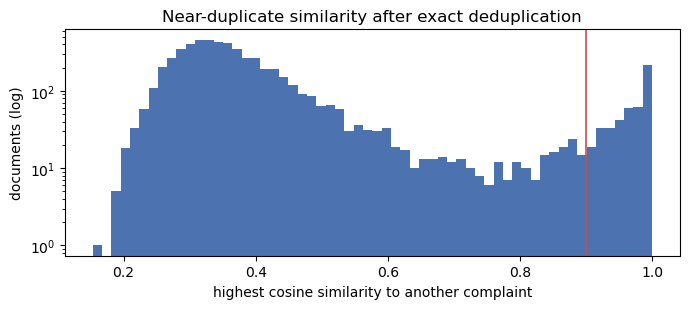

In [13]:
fig, ax = plt.subplots(figsize=(7, 3.2))
ax.hist(best, bins=60, color="#4c72b0")
ax.axvline(0.9, color="#c44e52", lw=1.2)
ax.set_yscale("log")
ax.set_xlabel("highest cosine similarity to another complaint")
ax.set_ylabel("documents (log)")
ax.set_title("Near-duplicate similarity after exact deduplication")
plt.tight_layout()

In [14]:
(pd.DataFrame({"Product": dd[data.LABEL_COL].values[q], "best": best})
   .groupby("Product")["best"].apply(lambda s: round(100 * (s >= 0.9).mean(), 1))
   .rename("near-dup rate % (>=0.90)").to_frame())

,near-dup rate % (>=0.90)
Product,
Checking or savings account,1.7
Credit card,2.1
Debt collection,25.9
"Money transfer, virtual currency, or money service",5.3
Student loan,5.7


**Finding:** 7.8% of documents still have a ≥0.90 cosine near-duplicate after exact
deduplication, rising to 10.8% at ≥0.70. The distribution is bimodal: the median
document's closest neighbour sits at 0.36 and 82% fall below 0.5, but a distinct
cluster is pushed against 1.0. It is concentrated in Debt collection (25.9%)
against 1.7–5.7% elsewhere — template letters surviving in lightly edited form.

**Decision:** Carry on to two further questions before deciding anything. A
contamination *rate* only matters if it moves the metric, and grouping is only
safe if the clusters are well behaved — both are measured below.

## Near-duplicate cluster structure

Grouping the split means whole clusters move together, so the clusters have to be
inspected before that is agreed to. Connected components are transitive: if A~B
and B~C but A and C are unrelated, all three still land in one group. Left
unchecked that can collapse a corpus into one giant component, and a component
that spans several products would distort stratification.

Components over the full corpus take ~10 minutes, so they are computed once by
`python -m scripts.build_splits` and frozen next to the split indices.

In [15]:
clusters = dedup.load_clusters("../data/splits/near_dup_clusters.npy", expected_rows=len(dd))
sizes = np.bincount(clusters)
multi = sizes[sizes > 1]

pd.Series({
    "threshold": dedup.CLUSTER_THRESHOLD,
    "clusters": len(sizes),
    "singletons": int((sizes == 1).sum()),
    "multi-row clusters": len(multi),
    "rows inside them": int(multi.sum()),
    "share of corpus %": round(100 * multi.sum() / len(dd), 2),
}).to_frame("value")

,value
threshold,0.70
clusters,93805.00
singletons,91324.00
multi-row clusters,2481.00
rows inside them,10478.00
share of corpus %,10.29


In [16]:
pd.Series({
    "median": int(np.median(multi)),
    "p90": int(np.quantile(multi, 0.90)),
    "p95": int(np.quantile(multi, 0.95)),
    "p99": int(np.quantile(multi, 0.99)),
    "max": int(multi.max()),
}).to_frame("multi-row cluster size")

,multi-row cluster size
median,2
p90,4
p95,6
p99,30
max,696


In [17]:
counts = pd.Series(multi).value_counts().sort_index()
pd.concat([counts.head(6), pd.Series({">10": int((multi > 10).sum())})]).to_frame("clusters")

,clusters
2,1912
3,266
4,97
5,63
6,36
7,19
>10,59


In [18]:
# A cluster spanning several products would push the split off stratification.
per_cluster = pd.DataFrame({"c": clusters, "y": dd[data.LABEL_COL].values})
n_products = per_cluster.groupby("c")["y"].nunique()
mixed = n_products[n_products > 1].index

print("clusters spanning >1 product: %d" % len(mixed))
print("rows involved: %d (%.2f%%)" % (sizes[mixed].sum(), 100 * sizes[mixed].sum() / len(dd)))
print("largest mixed cluster: %d rows" % sizes[mixed].max())
for c in mixed[np.argsort(-sizes[mixed])][:3]:
    print(f"  cluster {c} (n={sizes[c]}):",
          {data.SHORT_LABELS[k]: v for k, v in per_cluster[per_cluster.c == c]["y"].value_counts().items()})

clusters spanning >1 product: 128
rows involved: 1177 (1.16%)
largest mixed cluster: 298 rows
  cluster 2578 (n=298): {'Money transfer': 297, 'Checking/savings': 1}
  cluster 22665 (n=152): {'Debt collection': 150, 'Credit card': 2}
  cluster 29783 (n=129): {'Debt collection': 127, 'Credit card': 2}


**Finding:** 93,805 clusters. 91,324 are singletons; the 2,481 multi-row clusters
hold 10,478 rows, 10.3% of the corpus. Sizes are small — median 2, p90 4, p95 6 —
and 1,912 of them are simple pairs. Transitive chaining is real but contained: the
largest component is 696 rows, 0.7% of the corpus, so nothing collapses into a
giant group.

128 clusters span more than one product (1.16% of rows), and each is dominated by
a single label — the largest is 297 Money transfer against 1 Checking/savings.
These are the same generic credit-report disputes found in the exact-duplicate
check, so a mixed cluster is a label-boundary case rather than a clustering
failure.

**Decision:** The cluster structure is safe to group on. Small clusters, no giant
component, and mixed-class clusters too rare and too lopsided to move
stratification.

## Check the target

In [19]:
summary = data.class_summary(dd[data.LABEL_COL])
summary["raw_n"] = df[data.LABEL_COL].value_counts()
summary["lost_to_dedup_%"] = (100 * (1 - summary["n"] / summary["raw_n"])).round(1)
summary

,n,pct,raw_n,lost_to_dedup_%
Product,,,,
Checking or savings account,21524,21.14,21547,0.1
"Money transfer, virtual currency, or money service",20940,20.57,21437,2.3
Credit card,20684,20.32,20890,1.0
Student loan,19985,19.63,20111,0.6
Debt collection,18669,18.34,24007,22.2


In [20]:
print("largest / smallest :", summary["n"].max(), "/", summary["n"].min())
print("class ratio        : %.3f:1" % (summary["n"].max() / summary["n"].min()))
print("ratio before dedup : %.3f:1" % (df[data.LABEL_COL].value_counts().max()
                                       / df[data.LABEL_COL].value_counts().min()))

largest / smallest : 21524 / 18669
class ratio        : 1.153:1
ratio before dedup : 1.194:1


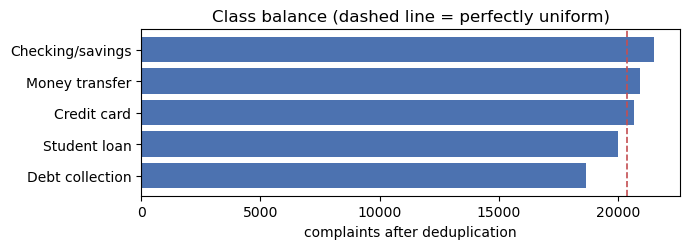

In [21]:
fig, ax = plt.subplots(figsize=(7, 2.6))
s = summary["n"].rename(index=data.SHORT_LABELS).sort_values()
ax.barh(s.index, s.values, color="#4c72b0")
ax.axvline(len(dd) / 5, color="#c44e52", lw=1.2, ls="--")
ax.set_xlabel("complaints after deduplication")
ax.set_title("Class balance (dashed line = perfectly uniform)")
plt.tight_layout()

**Finding:** 101,802 rows split 18,669–21,524, a 1.153:1 ratio — *flatter* than the
1.194:1 in the plan, because deduplication removed proportionally more Debt
collection. The smallest class still holds 18.3% of the data against a uniform
20%. Every class has ~19k training examples; none is rare in any practical sense.

**Decision:** Keep class weights excluded, as pre-registered. At 1.15:1 the
reweighting a class-weighted loss applies is at most ×1.15, which is not a
mechanism that moves macro-F1 on 19k examples per class. The exclusion in
`project_plan.md` §3.3 is now backed by the deduplicated numbers rather than the
raw ones. Update the plan's stated ratio to the post-dedup value.

## Check text length

In [22]:
words = dd[n].str.split().str.len()
chars = dd[n].str.len()
pd.DataFrame({"words": text.length_summary(words), "characters": text.length_summary(chars)})

,words,characters
min,1.0,6.0
mean,226.5,1352.9
std,214.8,1306.2
p50,178.0,1051.0
p75,288.0,1745.0
p90,436.0,2652.0
p95,570.0,3462.0
p99,1006.0,6077.0
max,5699.0,31995.0


In [23]:
by_class = (dd.assign(w=words).groupby(data.LABEL_COL)["w"]
              .agg(median="median", p75=lambda s: s.quantile(.75),
                   p90=lambda s: s.quantile(.90), mean="mean").round(0))
by_class["trunc@128_%"] = (dd.assign(t=words > 128).groupby(data.LABEL_COL)["t"]
                             .mean().mul(100).round(1))
by_class["trunc@256_%"] = (dd.assign(t=words > 256).groupby(data.LABEL_COL)["t"]
                             .mean().mul(100).round(1))
by_class.rename(index=data.SHORT_LABELS)

,median,p75,p90,mean,trunc@128_%,trunc@256_%
Product,,,,,,
Checking/savings,189.0,301.0,454.0,238.0,68.1,33.3
Credit card,207.0,319.0,470.0,252.0,72.2,37.0
Debt collection,155.0,264.0,395.0,202.0,60.3,26.3
Money transfer,167.0,269.0,402.0,214.0,62.5,27.2
Student loan,171.0,285.0,443.0,224.0,62.3,29.5


In [24]:
text.truncation_table(words, [64, 128, 192, 256, 384, 512])

,truncated_%,tokens_kept_%
max_len,,
64,86.1,26.7
128,65.2,48.1
192,46.1,63.8
256,30.8,74.6
384,13.5,86.5
512,6.6,91.9


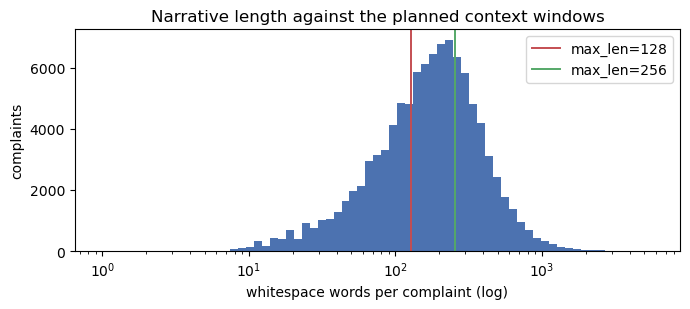

In [25]:
fig, ax = plt.subplots(figsize=(7, 3.2))
ax.hist(words, bins=np.logspace(0, np.log10(words.max()), 70), color="#4c72b0")
for m, c in [(128, "#c44e52"), (256, "#55a868")]:
    ax.axvline(m, color=c, lw=1.4, label=f"max_len={m}")
ax.set_xscale("log")
ax.set_xlabel("whitespace words per complaint (log)")
ax.set_ylabel("complaints")
ax.set_title("Narrative length against the planned context windows")
ax.legend()
plt.tight_layout()

Whitespace words are a stand-in here, not a model token count — the tokenizer-level
measurement is further down and is what the `max_len` decision actually rests on.

**Finding:** Median 178 words, p90 436, max 5,699, and a very heavy right tail
(mean 227 > median 178, std 215). At `max_len=128` 65% of complaints are cut and
the model reads 48% of all text; at 256, 31% are cut and 75% survives. Class
medians span 155 (Debt collection) to 207 (Credit card), so truncation bites
unevenly — 72% of Credit card complaints are cut at 128 against 60% of Debt
collection. 203 complaints are under 10 words; the shortest is 1 word.

**Decision:** Keep the pre-registered ladder — M0–M3 at 128, M4 at 256. The audit
supports it rather than forcing a change: 128 is aggressive enough that the
context increase in M4 has something real to recover (48% → 75% of tokens), which
is the comparison M4 exists to make. Very short complaints are kept; they are
genuine complaints, and 203 rows cannot distort training.

## Text quality

In [26]:
text.artifact_counts(dd[n])

,docs,pct
artifact,,
XXXX redaction,88331,86.77
XX/XX date,53154,52.21
year> placeholder,28036,27.54
{$...} amount,45747,44.94
bytes repr wrapper,673,0.66
url,178,0.17
email,14,0.01
html tag,8,0.01
non-ascii,0,0.00


In [27]:
# The `b'...'` rows are a byte-string repr that survived into the extract.
wrapped = dd[n].str.startswith("b'") | dd[n].str.startswith('b"')
print("rows:", int(wrapped.sum()), "| %.2f%%" % (100 * wrapped.mean()))
print(dd.loc[wrapped, data.LABEL_COL].value_counts().to_dict())
print()
print("raw     :", dd.loc[wrapped, n].iloc[1][:150])
print("unwrapped:", text.strip_bytes_wrapper(dd.loc[wrapped, n].iloc[1])[:150])

rows: 673 | 0.66%
{'Money transfer, virtual currency, or money service': 191, 'Credit card': 173, 'Checking or savings account': 140, 'Debt collection': 128, 'Student loan': 41}

raw     : b"Sofi, after XXXX  dispute XXXX XXXX appeals, XXXX  a police scam report, a identity theft affidavit, a court bank records subpoena, as scam criminal
unwrapped: Sofi, after XXXX  dispute XXXX XXXX appeals, XXXX  a police scam report, a identity theft affidavit, a court bank records subpoena, as scam criminal i


In [28]:
top_share = dd[n].str.split().apply(lambda t: Counter(t).most_common(1)[0][1] / len(t))
upper = dd[n].str.count(r"[A-Z]") / dd[n].str.len()
digits = dd[n].str.count(r"\d") / dd[n].str.len()
pd.Series({
    "one token is >30% of the doc": int((top_share > 0.30).sum()),
    "over 60% uppercase chars": int((upper > 0.60).sum()),
    "over 20% digit chars": int((digits > 0.20).sum()),
    "under 10 words": int((words < 10).sum()),
    "over 1000 words": int((words > 1000).sum()),
}).to_frame("documents")

,documents
one token is >30% of the doc,364
over 60% uppercase chars,415
over 20% digit chars,6
under 10 words,203
over 1000 words,1032


**Finding:** The text is messy in ways that are mostly meaningful. URLs (0.17%),
emails (0.01%), HTML (0.01%) and non-ASCII (0%) are all negligible. Real
structural artifacts: 49% of narratives contain blank lines, and 415 documents are
more than 60% uppercase — consumers shouting, which is signal about tone rather
than noise. 673 rows (0.66%) are wrapped in a `b'...'` byte-repr with literal
`\n` escapes; they appear in all five classes rather than concentrating in one,
so they are noise and not a class marker.

**Decision:** Strip the `b'...'` wrapper and unescape those 673 rows at
preprocessing (`src.text.strip_bytes_wrapper`) — it is unambiguous encoding damage
and removes nothing a reader would keep. Leave casing, punctuation, repetition and
blank lines alone: lowercasing is already the tokenizer's job for both Keras and
DistilBERT, and the rest is how consumers actually write.

## Inspect redactions

CFPB replaces names, dates and amounts with placeholders before publication. If
those placeholders appear at different rates per class, a model could pick up the
redaction pattern instead of the complaint — and that shortcut would vanish on
un-redacted text.

In [29]:
x_count = text.count_matches(dd[n], r"\bX{2,}\b")
print("complaints containing XXXX: %d (%.1f%%)" % ((x_count > 0).sum(),
                                                   100 * (x_count > 0).mean()))
text.length_summary(x_count).to_frame("XXXX per complaint")

complaints containing XXXX: 88331 (86.8%)


,XXXX per complaint
min,0.0
mean,13.8
std,28.5
p50,7.0
p75,17.0
p90,32.0
p95,46.0
p99,100.0
max,4306.0


In [30]:
red = dd.assign(x=x_count, w=words, dens=100 * x_count / words)
pd.DataFrame({
    "has XXXX %": red.groupby(data.LABEL_COL)["x"].apply(lambda s: 100 * (s > 0).mean()).round(1),
    "mean count": red.groupby(data.LABEL_COL)["x"].mean().round(1),
    "median count": red.groupby(data.LABEL_COL)["x"].median(),
    "median density %": red.groupby(data.LABEL_COL)["dens"].median().round(2),
}).rename(index=data.SHORT_LABELS)

,has XXXX %,mean count,median count,median density %
Product,,,,
Checking/savings,88.9,14.1,8.0,4.29
Credit card,89.6,15.2,9.0,4.53
Debt collection,81.6,11.8,6.0,4.03
Money transfer,86.2,13.2,7.0,4.48
Student loan,86.9,14.6,7.0,4.80


In [31]:
for label in ["Credit card", "Debt collection"]:
    row = dd[dd[data.LABEL_COL] == label].iloc[3]
    print(f"--- {label} ---")
    print(row[n][:260], "\n")

--- Credit card ---
I was approached by a XXXX store associate who offered me a rewards card. I was not informed that this was a credit card or that signing up would result in a hard inquiry on my credit report. I believed I was signing up for a simple rewards/loyalty program, no 

--- Debt collection ---
I'm not sure why! We change our insurance company when our policy window came to an end. We were told by XXXX XXXX ; they would drop us if we didn't pay. We were looking for another company at the time to lower our rates, which started to get out of hand. When 



**Finding:** 86.8% of complaints contain `XXXX`, mean 13.8 per complaint, median 7,
max 4,306. Class-wise the spread is narrow: presence 81.6%–89.6%, median density
4.03%–4.80% of tokens. `project_plan.md` §2 flags a Credit card (15.2) vs Debt
collection (9.5) gap in mean count — the deduplicated means are 15.2 vs 11.8, and
once normalised by length the gap is 4.53% vs 4.03%. Mean count tracks complaint
length, not product.

**Decision:** Keep `XXXX` in the text, and confirm below with a direct shortcut
probe before treating that as settled. Two reasons to keep it: at ~4.6% of all
tokens it is the single most frequent token in the corpus, and removing it would
delete the positional evidence that something was named there. It is also in the
GloVe vocabulary and tokenises to 2 WordPieces, so neither embedding path chokes
on it.

## Vocabulary

In [32]:
seqs = [text.keras_word_sequence(t) for t in dd[n]]
vocab = Counter()
for s in seqs:
    vocab.update(s)
total = sum(vocab.values())
print("vocabulary size :", len(vocab))
print("total tokens    :", total)
print("hapax           : %d (%.0f%% of types)" % (sum(1 for c in vocab.values() if c == 1),
                                                  100 * sum(1 for c in vocab.values() if c == 1) / len(vocab)))
pd.DataFrame([{"max_features": k,
               "corpus tokens covered %": round(100 * sum(c for _, c in vocab.most_common(k)) / total, 2)}
              for k in (5000, 10000, 20000, 30000, 50000)]).set_index("max_features")

vocabulary size : 57396
total tokens    : 23174386
hapax           : 27351 (48% of types)


,corpus tokens covered %
max_features,
5000,98.05
10000,99.36
20000,99.78
30000,99.88
50000,99.97


In [33]:
pd.Series(dict(vocab.most_common(15))).to_frame("count")

,count
xxxx,1057854
the,981365
i,734410
to,707881
and,653709
my,471067
a,450863
of,412261
xx,324831
that,317534


In [34]:
from sklearn.feature_extraction.text import CountVectorizer

cv = CountVectorizer(min_df=20, max_features=30000)
counts = cv.fit_transform(dd[n])
terms = cv.get_feature_names_out()

distinctive = {
    data.SHORT_LABELS[label]: text.top_terms_by_log_odds(
        counts, terms, (dd[data.LABEL_COL] == label).values, k=12)
    for label in data.LABELS
}
pd.DataFrame(distinctive)

,Checking/savings,Credit card,Debt collection,Money transfer,Student loan
0,webster,jetblue,1618d,abound,edfinancial
1,chexsystems,elan,credence,kraken,pslf
2,cd,citicard,waypoint,offenders,mohelas
3,marcus,comenitys,aldous,moneygram,ibr
4,etrade,lowe,procollect,abra,mohela
5,novo,barclay,sequium,unfeasible,idr
6,hsa,carecredit,tsi,infeasible,studentaid
7,axos,aadvantage,fco,remitlys,navient
8,229,kohls,ncs,eth,nelnet
9,matured,citicards,jefferson,krakens,ferpa


In [35]:
# How much vocabulary the classes actually share.
top_sets = {}
for label in data.LABELS:
    c = np.asarray(counts[(dd[data.LABEL_COL] == label).values].sum(0)).ravel()
    top_sets[data.SHORT_LABELS[label]] = set(terms[np.argsort(-c)[:2000]])
names = list(top_sets)
pd.DataFrame([[round(len(top_sets[a] & top_sets[b]) / len(top_sets[a] | top_sets[b]), 2)
               for b in names] for a in names], index=names, columns=names)

,Checking/savings,Credit card,Debt collection,Money transfer,Student loan
Checking/savings,1.00,0.74,0.58,0.79,0.60
Credit card,0.74,1.00,0.62,0.68,0.62
Debt collection,0.58,0.62,1.00,0.56,0.58
Money transfer,0.79,0.68,0.56,1.00,0.57
Student loan,0.60,0.62,0.58,0.57,1.00


**Finding:** 57,396 word types over 23.2M tokens, with 48% of types appearing once.
The head is dominated by function words plus `xxxx`, which alone is 4.6% of the
corpus. The top 20,000 words cover 99.78% of all tokens, so the tail contributes
very little token mass — that is a statement about frequency, not about which
words matter for classification. Some rare words are highly discriminative, as
the distinctive-term list below shows.

The distinctive terms are servicer and brand names — `mohela`, `navient`,
`aidvantage`, `pslf` for Student loan; `coinbase`, `zelle`, `binance`, `moneygram`
for Money transfer; `procollect`, `sequium`, `fdcpa` for Debt collection. Jaccard
overlap of each class's top 2,000 terms is 0.57–0.79, so the classes share most of
their common vocabulary and separate on a comparatively small distinctive set.

**Decision:** Set `max_features=20000` as a practical cutoff under the project's
compute budget: it buys 99.78% token mass while going to 30,000 adds 0.10pp and
10,000 embedding rows each trained from ~2 examples. The effect of vocabulary
size on classification performance is not independently isolated here — if a
later error analysis implicates OOV coverage, this is the knob to revisit.
Out-of-vocabulary words map to a reserved `<OOV>` token rather than being
dropped, so sequence length stays independent of vocabulary size and the
truncation figures above hold.

## Check leakage

Two things to separate: a *shortcut*, where the label is recoverable from something
that is not the complaint's content, and *lexical separability*, where the task is
genuinely easy because complaints name their product. The first invalidates the
experiment; the second is the dataset behaving normally.

In [36]:
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import f1_score
from sklearn.model_selection import train_test_split

# Can the label be predicted from redaction and formatting counts alone,
# with every word thrown away?
probe = pd.DataFrame({
    "xxxx": x_count.values,
    "amounts": dd[n].str.count(r"\{\$[\d.,]+\}").values,
    "dates": dd[n].str.count(r"XX/XX/").values,
    "words": words.values,
})
probe["xxxx_density"] = probe.xxxx / probe.words
y = dd[data.LABEL_COL].values
ptr, pte, ytr, yte = train_test_split(probe, y, test_size=0.2, random_state=42, stratify=y)

for name, cols in [("redaction only", ["xxxx", "amounts", "dates", "xxxx_density"]),
                   ("length only", ["words"]),
                   ("redaction + length", list(probe.columns))]:
    m = HistGradientBoostingClassifier(max_iter=150, random_state=42).fit(ptr[cols], ytr)
    print("%-20s macro-F1 %.3f" % (name, f1_score(yte, m.predict(pte[cols]), average="macro")))
print("%-20s macro-F1 %.3f" % ("random guess", 0.200))

redaction only       macro-F1 0.274


length only          macro-F1 0.228


redaction + length   macro-F1 0.286
random guess         macro-F1 0.200


**Finding:** Redaction counts alone reach 0.274 macro-F1 and adding length reaches
0.286, against 0.200 for guessing. There is a weak signal — longer complaints
carry more redactions and some products attract longer complaints — but it is
nowhere near a shortcut. For comparison the lexical reference below scores 0.86.

**Decision:** Confirms the redaction decision above: keep `XXXX`. Recorded as a
known weak confound rather than a threat. If a model ever lands near 0.29 macro-F1
this is the explanation to check first.

In [37]:
# Do complaints name their own product?
cues = {
    "Checking or savings account": r"checking account|savings account|overdraft",
    "Credit card": r"credit card",
    "Debt collection": r"debt collector|collection agency|fdcpa",
    "Money transfer, virtual currency, or money service": r"zelle|venmo|paypal|cash app|crypto|wire transfer",
    "Student loan": r"student loan|navient|mohela|nelnet",
}
low = dd[n].str.lower()
rows = []
for label, pattern in cues.items():
    hit = low.str.contains(pattern, regex=True)
    inside = (dd[data.LABEL_COL] == label).values
    rows.append({"class": data.SHORT_LABELS[label],
                 "cue in class %": round(100 * hit[inside].mean(), 1),
                 "cue elsewhere %": round(100 * hit[~inside].mean(), 1)})
pd.DataFrame(rows).set_index("class")

,cue in class %,cue elsewhere %
class,,
Checking/savings,27.6,3.2
Credit card,47.5,3.3
Debt collection,40.2,1.0
Money transfer,49.2,3.1
Student loan,70.9,0.2


**Finding:** Product-naming phrases appear in 28–71% of their own class and 0.2–3.3%
of the others. Strong, but this is a consumer describing what the complaint is
about — the realistic signal any deployed classifier would use. No class is near
100%, so the task does not reduce to a keyword lookup.

**Decision:** No action. Documented so a high baseline score is not later
misread as leakage.

## TF-IDF reference

Auxiliary check from `project_plan.md` §9.2, and the instrument for sizing the
near-duplicate problem. It is not M0 and not one of the six configurations.

The split here is a throwaway audit split, not the frozen project split — that is
created in Stage 2.

In [38]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

idx_tr, idx_te = train_test_split(np.arange(len(dd)), test_size=0.10,
                                  random_state=42, stratify=y)
vec = TfidfVectorizer(min_df=3, max_features=60000, sublinear_tf=True,
                      strip_accents="unicode")
Xtr = vec.fit_transform(dd[n].iloc[idx_tr])
Xte = vec.transform(dd[n].iloc[idx_te])
clf = LogisticRegression(max_iter=400, C=4.0).fit(Xtr, y[idx_tr])
pred = clf.predict(Xte)
print(classification_report(y[idx_te], pred, digits=3))

                                                    precision    recall  f1-score   support

                       Checking or savings account      0.756     0.790     0.772      2153
                                       Credit card      0.861     0.845     0.853      2068
                                   Debt collection      0.913     0.924     0.918      1867
Money transfer, virtual currency, or money service      0.820     0.799     0.809      2094
                                      Student loan      0.972     0.958     0.965      1999

                                          accuracy                          0.860     10181
                                         macro avg      0.864     0.863     0.863     10181
                                      weighted avg      0.861     0.860     0.861     10181



In [39]:
pd.DataFrame(confusion_matrix(y[idx_te], pred, labels=data.LABELS),
             index=[data.SHORT_LABELS[l] for l in data.LABELS],
             columns=[data.SHORT_LABELS[l] for l in data.LABELS])

,Checking/savings,Credit card,Debt collection,Money transfer,Student loan
Checking/savings,1700,139,18,291,5
Credit card,157,1747,91,62,11
Debt collection,21,80,1725,11,30
Money transfer,360,46,6,1673,9
Student loan,12,18,50,4,1915


**Finding:** Macro-F1 0.863, accuracy 0.860 from bag-of-words alone. Per-class F1
runs 0.772 (Checking/savings) to 0.965 (Student loan), and the largest confusion is
Checking/savings ↔ Money transfer — both are account-level payment disputes, so
the confusion is semantic. Debt collection ↔ Credit card, the confusion the plan
predicts, is present but smaller.

**Decision:** No change to the ladder. The task is strongly lexical, which is
exactly the ground for the M1 hypothesis in §7 (word order matters less than
keyword presence). Recorded as the reference M0 is sanity-checked against — not as
a bar M0 must clear.

In [40]:
# How much of that 0.864 is near-duplicate contamination?
best_te = text.max_similarity(A[idx_te], A[idx_tr], exclude=None)
rows = []
for thr in (0.95, 0.90, 0.80):
    hit = best_te >= thr
    rows.append({
        "threshold": thr,
        "test docs with a train near-dup": int(hit.sum()),
        "%": round(100 * hit.mean(), 2),
        "macro-F1 on those": round(f1_score(y[idx_te][hit], pred[hit], average="macro"), 3),
        "macro-F1 on the rest": round(f1_score(y[idx_te][~hit], pred[~hit], average="macro"), 3),
    })
pd.DataFrame(rows).set_index("threshold")

,test docs with a train near-dup,%,macro-F1 on those,macro-F1 on the rest
threshold,,,,
0.95,541,5.31,0.924,0.859
0.90,724,7.11,0.922,0.858
0.80,890,8.74,0.889,0.858


In [41]:
# Which classes the contaminated test documents belong to.
(pd.Series(y[idx_te][best_te >= 0.90]).value_counts()
   .rename(index=data.SHORT_LABELS).rename("contaminated test docs").to_frame())

,contaminated test docs
Debt collection,412
Student loan,118
Money transfer,116
Credit card,53
Checking/savings,25


**Finding:** 7.1% of test documents have a ≥0.90 near-duplicate sitting in train.
The model scores 0.922 macro-F1 on them against 0.858 on the rest — a 6.4-point
gap on the slice it has effectively already seen. Weighting that gap by the
contaminated share (7.1%) means the contaminated slice contributes roughly 0.45
Macro-F1 points to the observed 0.863 aggregate relative to what it would
contribute if it scored like the clean slice. That is a statement about this
split's composition, not a claim about what a genuinely near-duplicate-free split
would score — that is checked directly once grouping is implemented (§14.4).

`project_plan.md` §9 treats an M0 seed spread of 0.8 F1 points as already large
enough to make ladder deltas unresolvable, so a 0.45-point contamination effect
sits in the same range as what the ladder is built to measure. 57% of the
contaminated documents are Debt collection, so per-class F1 is distorted more
unevenly than the aggregate suggests. 0.45 is plausibly a floor rather than the
full effect: it is what a linear bag-of-words model extracts from the
contamination, and higher-capacity sequence models — an LSTM or a fine-tuned
transformer — may be more susceptible to memorising a repeated template, though
that is a hypothesis this audit does not test.

**Decision:** Use a near-duplicate-aware split in Stage 2. Exact deduplication is
not enough; the split must keep near-duplicate clusters whole inside a single
split rather than letting members scatter across train, val and test. This does
not touch the locked experimental design: no rows are removed, the row count
stays 101,802, the 80/10/10 stratified proportions stay, and the six
configurations and 10 fits are unchanged. It has to be decided now because every
model in the project shares one frozen split — retrofitting it later invalidates
every result before it.

The clustering threshold is checked for structural soundness in the next section
before it is used, and Stage 2 re-measures the inflation band by band to set it
— see `project_plan.md` §14.4 and `src/dedup.py`. The live value is
`dedup.CLUSTER_THRESHOLD`, which is what the frozen config below records.

## Token lengths

Everything above counted whitespace words. Neither model sees those. The Keras
tokenizer splits on its punctuation filter, and DistilBERT's WordPiece splits
unknown words into subwords — which is exactly what financial jargon and
redaction markers are.

TensorFlow is not installed locally, so Keras lengths are computed with
`src.text.keras_word_sequence`, which applies the documented default `filters`,
`lower=True` and `split=" "` of `tf.keras.preprocessing.text.Tokenizer`. With
`oov_token` set, sequence length does not depend on `num_words`, so this is the
length the real tokenizer produces.

In [42]:
from transformers import AutoTokenizer

keras_len = np.array([len(s) for s in seqs])
wp_tok = AutoTokenizer.from_pretrained("distilbert-base-uncased")
wp_len = text.wordpiece_lengths(dd[n], wp_tok)

pd.DataFrame({
    "whitespace": text.length_summary(words),
    "keras": text.length_summary(keras_len),
    "distilbert wordpiece": text.length_summary(wp_len),
})

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (1015 > 512). Running this sequence through the model will result in indexing errors


,whitespace,keras,distilbert wordpiece
min,1.0,1.0,5.0
mean,226.5,227.6,292.0
std,214.8,214.7,286.1
p50,178.0,180.0,228.0
p75,288.0,290.0,369.0
p90,436.0,438.0,563.0
p95,570.0,569.0,736.0
p99,1006.0,1008.0,1317.0
max,5699.0,5830.0,9071.0


In [43]:
print(wp_tok.tokenize("XXXX XX/XX/2024 {$1500.00} ACH chargeback overdraft Navient forbearance"))
print("wordpiece / keras length ratio: median %.2f, p90 %.2f"
      % (np.median(wp_len / keras_len), np.quantile(wp_len / keras_len, 0.9)))

['xx', '##xx', 'xx', '/', 'xx', '/', '202', '##4', '{', '$', '1500', '.', '00', '}', 'ac', '##h', 'charge', '##back', 'over', '##dra', '##ft', 'na', '##vie', '##nt', 'for', '##be', '##aran', '##ce']
wordpiece / keras length ratio: median 1.26, p90 1.42


In [44]:
pd.concat({"keras": text.truncation_table(keras_len, [128, 256, 512]),
           "distilbert": text.truncation_table(wp_len, [128, 256, 512])}, axis=0)

truncated_%  tokens_kept_%
           max_len                            
keras      128             65.6           48.0
           256             31.0           74.6
           512              6.6           91.9
distilbert 128             74.4           39.2
           256             43.9           64.9
           512             12.5           86.8

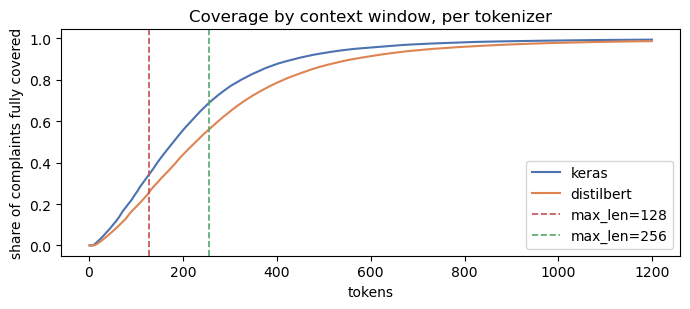

In [45]:
fig, ax = plt.subplots(figsize=(7, 3.2))
grid = np.arange(1, 1200)
for name, L, colour in [("keras", keras_len, "#4c72b0"), ("distilbert", wp_len, "#dd8452")]:
    ax.plot(grid, np.searchsorted(np.sort(L), grid, side="right") / len(L),
            label=name, color=colour)
for m, c in [(128, "#c44e52"), (256, "#55a868")]:
    ax.axvline(m, color=c, lw=1.2, ls="--", label=f"max_len={m}")
ax.set_xlabel("tokens")
ax.set_ylabel("share of complaints fully covered")
ax.set_title("Coverage by context window, per tokenizer")
ax.legend()
plt.tight_layout()

**Finding:** WordPiece inflates length by a median factor of 1.26 (p90 1.42).
Keras and whitespace counts agree closely (median 180 vs 178) since the filter only
splits on punctuation, but DistilBERT's median is 228.

| max_len | Keras truncated | DistilBERT truncated |
|---|---|---|
| 128 | 65.6% | 74.4% |
| 256 | 31.0% | 43.9% |

The cause is visible in the tokenisation sample: `XXXX` → `xx ##xx`, `navient` →
`na ##vie ##nt`, `overdraft` → `over ##dra ##ft`. The domain vocabulary and the
redaction marker are precisely what WordPiece has to split.

**Decision:** Keep M0–M3 at 128 and M4 at 256 as pre-registered — the audit
supports the plan and no change is proposed.

One gap: `project_plan.md` does not state a `max_len` for D0. Set **D0 = 256** to
match M4, so the headline D0-vs-M4 comparison holds nominal context constant. It
has to be recorded that this is not *equal* context: at 256, M4 reads 74.6% of the
tokens in the corpus and D0 reads 64.9% of its own. D0 is handicapped on context,
so if it wins anyway the conclusion is only stronger — and if it loses narrowly,
this is the first thing to check. Added to the plan as a stated limitation
alongside the existing M4 bundling caveat.

## GloVe coverage

M3 swaps random embeddings for GloVe 100d. That experiment is only informative if
GloVe actually has vectors for this vocabulary.

In [46]:
glove = embeddings.load_glove_vocab("../data/embeddings/glove.6B.100d.txt")
print("glove vocabulary:", len(glove))
embeddings.coverage(vocab, glove, [1000, 5000, 10000, 20000, 30000, None])

glove vocabulary: 400001


,types_in_glove_%,tokens_in_glove_%,corpus_covered_%
vocab_size,,,
1000,98.6,99.60,86.31
5000,97.2,99.32,97.39
10000,94.1,99.23,98.60
20000,86.5,99.16,98.94
30000,76.3,99.11,99.00
57396,53.0,99.03,99.03


In [47]:
pd.DataFrame(embeddings.missing_terms(vocab, glove, 20000, k=24),
             columns=["term", "corpus count"]).set_index("term")

,corpus count
term,
mohela,20791
fdcpa,8272
navient,6349
didn't,5575
i'm,5074
don't,4963
pslf,4338
i've,4180
coinbase,4102


In [48]:
# Coverage on the terms that actually separate the classes.
pd.DataFrame([
    {"class": short,
     "distinctive terms in glove": f"{sum(1 for t in terms_ if t in glove)}/{len(terms_)}"}
    for short, terms_ in {
        data.SHORT_LABELS[label]: text.top_terms_by_log_odds(
            counts, terms, (dd[data.LABEL_COL] == label).values, k=30)
        for label in data.LABELS}.items()
]).set_index("class")

,distinctive terms in glove
class,
Checking/savings,26/30
Credit card,21/30
Debt collection,23/30
Money transfer,15/30
Student loan,18/30


In [49]:
# Contractions miss because the Keras filter keeps the apostrophe and GloVe's
# tokenizer splits on it. Worth deviating from the default filters?
split_apostrophes = Counter()
for word, c in vocab.items():
    for part in (word.split("'") if "'" in word else [word]):
        if part:
            split_apostrophes[part] += c
pd.concat({"keras defaults": embeddings.coverage(vocab, glove, [20000]),
           "apostrophe stripped": embeddings.coverage(split_apostrophes, glove, [20000])})

,,types_in_glove_%,tokens_in_glove_%,corpus_covered_%
,vocab_size,,,
keras defaults,20000,86.5,99.16,98.94
apostrophe stripped,20000,87.4,99.35,99.14


**GloVe coverage = 99.16%** of tokens at `max_features=20000` (86.5% of types).
**OOV = 0.84%** of tokens, 13.5% of types.

**Finding:** Coverage looks excellent by token mass and is misleading. The 2,694
in-vocabulary words GloVe does not have are not random tail junk — they are the
class-distinctive ones: `mohela` (20,791 occurrences), `fdcpa`, `navient`, `pslf`,
`coinbase`, `cashapp`, `aidvantage`, `truist`, `lvnv`, `tradeline`, and statute
references like `1692g` and `1681i`. Of the 30 most distinctive terms per class,
GloVe covers 15/30 for Money transfer and 18/30 for Student loan against 26/30 for
Checking/savings. `xxxx` itself is in GloVe.

The other missing group is contractions — `didn't`, `i'm`, `don't` — because the
Keras filter keeps the apostrophe while GloVe's tokenizer splits it. Stripping
apostrophes too would lift token coverage from 99.16% to 99.35%: 0.19pp, for a
deviation from the tokenizer's documented defaults.

**Decision:** Run M3 as planned; coverage is high enough for the experiment to
mean something. Keep the Keras default filters — 0.19pp does not justify a custom
tokenizer. Two things recorded before the result is seen: the M3 hypothesis in
§7 should expect a *smaller* gain than "99% coverage" suggests, because the
highest-signal vocabulary is exactly what stays randomly initialised; and OOV
words map to `<OOV>` with the embedding matrix trainable, so those rows can still
learn from the 81k training complaints.

## Audit findings

| Finding | Evidence | Decision |
|---|---|---|
| Schema and labels as specified | 107,992 rows, 16 columns, 5 products, unique `Complaint ID`, 0 nulls or blanks | Use `Consumer complaint narrative` → `Product`; no relabelling |
| Heavy exact duplication | 7,038 rows over 848 texts; largest groups 832 / 293 / 238; 85% in Debt collection | Deduplicate on narrative before splitting → 101,802 rows |
| Ambiguous labels | 7 texts (49 rows) filed under more than one product | Keep. Label-noise floor of 0.05%; explains part of the Debt collection ↔ Credit card confusion |
| Near-duplicate leakage | 7.8% of docs have a ≥0.90 cosine twin; 25.9% within Debt collection | Exact dedup insufficient — Stage 2 split must keep near-dup clusters intact |
| Leakage is material | TF-IDF scores 0.922 macro-F1 on contaminated test docs vs 0.858 on clean ones (~0.5 F1 pts inflation, a floor for higher-capacity models) | Same range as the 0.8-pt spread §9 calls unresolvable — justifies the split change |
| Mild class imbalance | 1.153:1 after dedup (1.194:1 before); smallest class 18.3% | Keep class weights excluded, as pre-registered |
| Long right tail | median 178 words, p90 436, max 5,699 | Keep M0–M3 at 128, M4 at 256 |
| WordPiece inflates length | median ×1.26; 43.9% truncated at 256 vs 31.0% for Keras | Keep the ladder; set D0 `max_len=256` and state the unequal-context caveat |
| Redaction is not a shortcut | `XXXX` in 86.8% of docs; class density 4.03–4.80%; redaction-only probe 0.274 macro-F1 vs 0.200 chance | Keep `XXXX` in the text; logged as a weak confound |
| Encoding damage | 673 rows (0.66%) wrapped in `b'...'`, present in all five classes | Strip the wrapper at preprocessing |
| Task is strongly lexical | TF-IDF + LR reaches 0.863 macro-F1; class cues in 28–71% of own class vs 0.2–3.3% elsewhere | Realistic signal, not leakage; supports the M1 hypothesis |
| Vocabulary is long-tailed | 57,396 types, 48% hapax, top 20k covers 99.78% of tokens | `max_features=20000`, `<OOV>` token |
| GloVe misses the signal words | 99.16% token coverage but 15–26 of each class's top 30 distinctive terms present | Run M3; expect a smaller gain than raw coverage implies |

### Are we ready for preprocessing and training?

Yes, with one change carried into Stage 2.

The schema, labels and integrity are verified. Every removal is quantified and
justified. The two decisions that could have invalidated the experiment were
tested rather than assumed: redactions are not a class shortcut, and the strong
lexical separability is genuine complaint content rather than an artifact. The
pre-registered `max_len` ladder, the class-weight exclusion and the GloVe
experiment all survive the audit on evidence.

The one thing the audit changes is the split: near-duplicate contamination inflates
the metric by roughly the size of the effects the ladder measures, so the split
must be near-duplicate aware. That is a Stage 2 change and it is recorded in the
plan. Nothing about the six configurations, the 10 fits or the metric moves.

## Freeze the data config

In [50]:
import json
from pathlib import Path

data_config = {
    "dataset": {
        "path": "data/combined_complaints.parquet",
        "text_column": data.TEXT_COL,
        "label_column": data.LABEL_COL,
        "labels": data.LABELS,
        "rows_raw": int(len(df)),
        "rows_after_dedup": int(len(dd)),
    },
    "cleaning": {
        "deduplicate_on": "narrative, keep first",
        "rows_removed": int(len(df) - len(dd)),
        "strip_bytes_repr_wrapper": True,
        "keep_xxxx_redactions": True,
        "lowercase": "left to each tokenizer",
    },
    "split": {
        "train_val_test": [0.8, 0.1, 0.1],
        "stratify_on": data.LABEL_COL,
        "group_by": f"near-duplicate cluster, tfidf cosine >= {dedup.CLUSTER_THRESHOLD}",
        "seed": 42,
    },
    "keras_tokenizer": {
        "max_features": 20000,
        "oov_token": "<OOV>",
        "filters": text.KERAS_FILTERS,
        "lower": True,
        "max_len": {"M0": 128, "M1": 128, "M2": 128, "M3": 128, "M4": 256},
    },
    "distilbert": {
        "checkpoint": "distilbert-base-uncased",
        "max_len": 256,
    },
    "glove": {
        "path": "data/embeddings/glove.6B.100d.txt",
        "dim": embeddings.GLOVE_DIM,
        "trainable": True,
    },
    "class_weights": {"enabled": False, "reason": "class ratio 1.153:1 after dedup"},
    "audit": {
        "class_ratio": round(float(summary["n"].max() / summary["n"].min()), 3),
        "words_median": int(words.median()),
        "words_p90": int(words.quantile(0.90)),
        "keras_truncated_at_128_%": float(text.truncation_table(keras_len, [128]).loc[128, "truncated_%"]),
        "keras_truncated_at_256_%": float(text.truncation_table(keras_len, [256]).loc[256, "truncated_%"]),
        "wordpiece_truncated_at_128_%": float(text.truncation_table(wp_len, [128]).loc[128, "truncated_%"]),
        "wordpiece_truncated_at_256_%": float(text.truncation_table(wp_len, [256]).loc[256, "truncated_%"]),
        "vocabulary_types": len(vocab),
        "glove_token_coverage_%": float(embeddings.coverage(vocab, glove, [20000]).loc[20000, "tokens_in_glove_%"]),
        "glove_oov_token_%": round(100 - float(embeddings.coverage(vocab, glove, [20000]).loc[20000, "tokens_in_glove_%"]), 2),
        "xxxx_present_%": round(float(100 * (x_count > 0).mean()), 1),
        "near_duplicate_rate_at_0.90_%": round(float(100 * (best >= 0.90).mean()), 1),
        "near_duplicate_rate_at_grouping_threshold_%": round(float(100 * (best >= dedup.CLUSTER_THRESHOLD).mean()), 1),
        "tfidf_reference_macro_f1": round(float(f1_score(y[idx_te], pred, average="macro")), 3),
    },
}

Path("../configs").mkdir(exist_ok=True)
Path("../configs/data_config.json").write_text(json.dumps(data_config, indent=2), encoding="utf-8")
print(json.dumps(data_config, indent=2))

{
  "dataset": {
    "path": "data/combined_complaints.parquet",
    "text_column": "Consumer complaint narrative",
    "label_column": "Product",
    "labels": [
      "Checking or savings account",
      "Credit card",
      "Debt collection",
      "Money transfer, virtual currency, or money service",
      "Student loan"
    ],
    "rows_raw": 107992,
    "rows_after_dedup": 101802
  },
  "cleaning": {
    "deduplicate_on": "narrative, keep first",
    "rows_removed": 6190,
    "strip_bytes_repr_wrapper": true,
    "keep_xxxx_redactions": true,
    "lowercase": "left to each tokenizer"
  },
  "split": {
    "train_val_test": [
      0.8,
      0.1,
      0.1
    ],
    "stratify_on": "Product",
    "group_by": "near-duplicate cluster, tfidf cosine >= 0.7",
    "seed": 42
  },
  "keras_tokenizer": {
    "max_features": 20000,
    "oov_token": "<OOV>",
    "filters": "!\"#$%&()*+,-./:;<=>?@[\\]^_`{|}~\t\n",
    "lower": true,
    "max_len": {
      "M0": 128,
      "M1": 128,
      "

Every value above traces to a measurement in this notebook. `max_features`,
`max_len`, the class-weight exclusion, the grouped split and the GloVe settings
are the audit's outputs, not defaults.

Stage 2 builds the split from this config.